# Aprendizado de Máquina - E01

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data      # features
y = iris.target    # classes

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


In [ ]:
import numpy as np

print("Distribuição no dataset completo:", np.bincount(y))
print("Distribuição no treino:", np.bincount(y_train))
print("Distribuição no teste:", np.bincount(y_test))

Distribuição no dataset completo: [50 50 50]
Distribuição no treino: [40 40 40]
Distribuição no teste: [10 10 10]


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Acurácia no treino:", train_accuracy)
print("Acurácia no teste:", test_accuracy)

Acurácia no treino: 1.0
Acurácia no teste: 0.9333333333333333


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

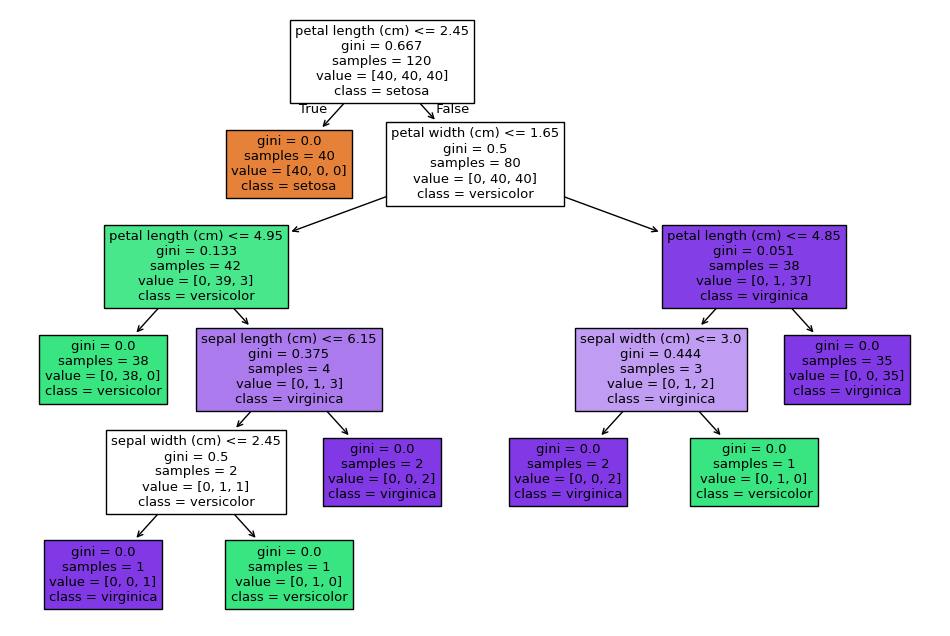

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

O atributo que aparece na raiz é `petal length (cm)`.

A profundidade da árvore é `5` - níveis desconsiderando a raiz (nível 0). E isso também pode ser verificado com código:

In [ ]:
print(model.get_depth())

5


# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [ ]:
import pandas as pd
# from sklearn.tree import DecisionTreeClassifier

resultados = []

depths = [1,2,3,4,5,6,7,8,9,None]

for d in depths:

    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    profundidade = model.get_depth()
    folhas = model.get_n_leaves()

    resultados.append([
        d,
        train_acc,
        test_acc,
        profundidade,
        folhas
    ])

tabela = pd.DataFrame(
    resultados,
    columns=[
        "max_depth",
        "acuracia_treino",
        "acuracia_teste",
        "profundidade_arvore",
        "numero_folhas"
    ]
)

print(tabela)

   max_depth  acuracia_treino  acuracia_teste  profundidade_arvore  \
0        1.0         0.666667        0.666667                    1   
1        2.0         0.971429        0.888889                    2   
2        3.0         0.980952        0.977778                    3   
3        4.0         0.990476        0.888889                    4   
4        5.0         1.000000        0.933333                    5   
5        6.0         1.000000        0.933333                    5   
6        7.0         1.000000        0.933333                    5   
7        8.0         1.000000        0.933333                    5   
8        9.0         1.000000        0.933333                    5   
9        NaN         1.000000        0.933333                    5   

   numero_folhas  
0              2  
1              3  
2              5  
3              7  
4              8  
5              8  
6              8  
7              8  
8              8  
9              8  


**Em qual profundidade começa o overfitting?** em `max_depth = 4`

O melhor desempenho no teste ocorre em profundidade 3 (0.9667). A partir de profundidade 4, a acurácia no treino continua aumentando e a acurácia no teste diminui, o que caracteriza overfitting. A partir desse ponto, o modelo passa a ajustar detalhes específicos do conjunto de treino que não generalizam bem para dados novos.

**Por que a árvore consegue 100% no treino quando max_depth=None?**

Quando `max_depth=None`, a árvore cresce livremente até separar completamente os dados de treino. Isso permite que o modelo memorize o conjunto de treinamento, resultando em 100% de acurácia no treino, mas sem necessariamente melhorar a generalização.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [ ]:
# import pandas as pd
# from sklearn.tree import DecisionTreeClassifier

criterios = ["gini", "entropy"]
resultados = []

for c in criterios:

    model = DecisionTreeClassifier(
        criterion=c,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    profundidade = model.get_depth()

    resultados.append([
        c,
        profundidade,
        train_acc,
        test_acc
    ])

tabela = pd.DataFrame(
    resultados,
    columns=[
        "criterion",
        "profundidade_arvore",
        "acuracia_treino",
        "acuracia_teste"
    ]
)

print(tabela)

  criterion  profundidade_arvore  acuracia_treino  acuracia_teste
0      gini                    5              1.0        0.933333
1   entropy                    6              1.0        0.888889


No caso, as tabelas devolveram os mesmos valores.

* **Gini** = mede impureza das classes e é o critério padrão do algoritmo
* **Entropy** = tem como base a teoria da informação e usa ganho de informação

Os dois critérios podem produzir árvores parecidas. E no caso, com um dataset relativamente pequeno como o Iris, as profundidades e acurácia saíram semelhantes, embora o critério Entropy tenha gerado uma árvore mais profunda (`6`) e com menos acurácia de teste (`0,888`) do que Gini (profundidade `5` e acurácia de teste `0,933`).

# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

O hiperparâmetro escolhido foi `max_depth`.

In [ ]:
# import pandas as pd
# from sklearn.tree import DecisionTreeClassifier

depths = [1,2,3,4,5,6,7,8,9,None]
resultados = []

for d in depths:

    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    resultados.append([
        d,
        train_acc,
        test_acc,
        model.get_depth(),
        model.get_n_leaves()
    ])

tabela = pd.DataFrame(
    resultados,
    columns=[
        "max_depth",
        "acuracia_treino",
        "acuracia_teste",
        "profundidade_real",
        "numero_folhas"
    ]
)

print(tabela)

   max_depth  acuracia_treino  acuracia_teste  profundidade_real  \
0        1.0         0.666667        0.666667                  1   
1        2.0         0.971429        0.888889                  2   
2        3.0         0.980952        0.977778                  3   
3        4.0         0.990476        0.888889                  4   
4        5.0         1.000000        0.933333                  5   
5        6.0         1.000000        0.933333                  5   
6        7.0         1.000000        0.933333                  5   
7        8.0         1.000000        0.933333                  5   
8        9.0         1.000000        0.933333                  5   
9        NaN         1.000000        0.933333                  5   

   numero_folhas  
0              2  
1              3  
2              5  
3              7  
4              8  
5              8  
6              8  
7              8  
8              8  
9              8  


Os resultados mostram que o hiperparâmetro `max_depth` tem impacto direto na complexidade da árvore de decisão. Quando `max_depth = 1`, tanto a acurácia de treino quanto a de teste são aproximadamente `0,67`. Ou seja, o modelo é simples demais para capturar os padrões do conjunto de dados, caracterizando **underfitting**.

À medida que a profundidade aumenta, o modelo passa a representar melhor os dados.

* `max_depth = 3` = a acurácia de treino é aproximadamente `0,981` e a acurácia de teste atinge cerca de `0,977`, que é o melhor resultado obtido. Nesse ponto, a árvore apresenta um bom equilíbrio entre capacidade de aprendizado e generalização para dados não vistos.
* `max_depth = 4` = a partir desse ponto, a acurácia de treino continua aumentando, enquanto a acurácia de teste diminui para aproximadamente `0,888`. Isso indica o início de **overfitting**, pois o modelo passa a se ajustar excessivamente ao conjunto de treinamento.
* `max_depth ≥ 5` = a acurácia de treino atinge `1,0` - ou seja, a árvore consegue classificar perfeitamente todas as amostras de treinamento. No entanto, a acurácia de teste permanece menor, pois a árvore passa a memorizar o conjunto de treino em vez de aprender padrões gerais. Além disso, a profundidade real da árvore permanece `5` e o número de folhas segue `8`, indicando que a estrutura máxima da árvore já foi alcançada para esse conjunto de dados.

Assim, o melhor modelo encontrado foi aquele com `max_depth = 3`, que apresentou a maior acurácia no conjunto de teste e melhor capacidade de generalização.